# SGD Classifier - Online Batch Learning
Train SGDClassifier using year-based batches to simulate online learning scenario

In [52]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
import warnings

## 1. Load Prepared Data and Split

In [53]:
# Load the prepared dataset with features
ds_path = Path('.') / 'training_data_with_features.zarr'
print(f'Loading data from {ds_path}...')
ds = xr.open_dataset(ds_path, engine='zarr')
print('✓ Data loaded')

# Load the train/val/test split
split_path = Path('.') / 'data_split.npz'
print(f'\nLoading split from {split_path}...')
split_data = np.load(split_path)
train_pixel_indices = split_data['train_pixel_indices']
val_pixel_indices = split_data['val_pixel_indices']
test_pixel_indices = split_data['test_pixel_indices']
print('✓ Split loaded')

print(f'\nDataset info:')
print(f'  Total pixels: {len(ds.pixel)}')
print(f'  Total years: {len(ds.year)}')
print(f'  Train pixels: {len(train_pixel_indices)}')
print(f'  Val pixels: {len(val_pixel_indices)}')
print(f'  Test pixels: {len(test_pixel_indices)}')

Loading data from training_data_with_features.zarr...
✓ Data loaded

Loading split from data_split.npz...
✓ Split loaded

Dataset info:
  Total pixels: 8155205
  Total years: 7
  Train pixels: 5597776
  Val pixels: 1273437
  Test pixels: 1283992


## 2. Feature Engineering
Prepare features from S2 bands, spectral indices, DEM, and temporal deltas

In [54]:
def prepare_features_for_year(ds, pixel_indices, year_idx, scaler=None):
    """
    Extract and normalize features for a specific year and set of pixels.
    - Skips year 0 entirely (no features returned)
    - Fills S2 band NaNs with per-pixel mean across all years
    - Drops samples that still contain NaNs (e.g., pixels where all years are NaN)
    - Filters out invalid labels (keeps only 0 and 1, removes 255)
    - Adds temporal deltas starting from year 1 (2017), where year 1 delta = 2017 - 0
    
    Args:
        ds: xarray Dataset
        pixel_indices: array of pixel indices to extract
        year_idx: year index (0-based)
        scaler: StandardScaler instance (optional). If None, creates and fits a new one.
    
    Returns:
        X: normalized feature matrix (n_pixels, n_features)
        y: labels (n_pixels,)
        scaler: the scaler used (fitted if it was None)
    """
    # Skip year 0 entirely
    if year_idx == 0:
        return np.empty((0, 0)), np.empty((0,)), scaler

    # Precompute per-pixel S2 means across all years for imputation
    s2_all_years = ds['s2_bands'].isel(pixel=pixel_indices).values  # (pixels, year, band)
    s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)

    # Extract data for selected pixels and target year
    ds_subset = ds.isel(pixel=pixel_indices, year=year_idx)

    # S2 bands (flatten across bands)
    s2_features = ds_subset['s2_bands'].values  # (n_pixels, n_s2_bands)
    # Fill NaNs in S2 with per-pixel mean over years
    if np.isnan(s2_features).any():
        # broadcast mean to same shape and fill
        s2_features = np.where(np.isnan(s2_features), s2_mean_per_pixel, s2_features)

    # DEM
    dem_features = ds_subset['dem'].values.reshape(-1, 1)  # (n_pixels, 1)

    # Spectral indices
    ndvi_features = ds_subset['ndvi'].values.reshape(-1, 1)
    ndwi_features = ds_subset['ndwi'].values.reshape(-1, 1)

    # Start with base features
    features_list = [s2_features, dem_features, ndvi_features, ndwi_features]

    # Add NBR if available
    if 'nbr' in ds.data_vars:
        nbr_features = ds_subset['nbr'].values.reshape(-1, 1)
        features_list.append(nbr_features)

    # Add temporal deltas if available
    # Delta starts from year 1: delta[0] = year[1] - 0 (2017 - 0)
    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:
        # Delta index is offset by 1: delta[0] = year[1] - 0
        delta_year_idx = year_idx - 1
        ds_delta = ds.isel(pixel=pixel_indices, year=delta_year_idx)
        ndvi_delta = ds_delta['ndvi_delta'].values.reshape(-1, 1)
        ndwi_delta = ds_delta['ndwi_delta'].values.reshape(-1, 1)
        features_list.extend([ndvi_delta, ndwi_delta])

        if 'nbr_delta' in ds.data_vars:
            nbr_delta = ds_delta['nbr_delta'].values.reshape(-1, 1)
            features_list.append(nbr_delta)

    # Add new temporal features (no data leakage - computed from prior years only)
    if 'years_since_last_disturbance' in ds.data_vars:
        years_since_features = ds_subset['years_since_last_disturbance'].values.reshape(-1, 1)
        features_list.append(years_since_features)
    
    if 'log_years_since_last_disturbance' in ds.data_vars:
        log_years_since_features = ds_subset['log_years_since_last_disturbance'].values.reshape(-1, 1)
        features_list.append(log_years_since_features)
    
    if 'ever_disturbed' in ds.data_vars:
        ever_disturbed_features = ds_subset['ever_disturbed'].values.reshape(-1, 1)
        features_list.append(ever_disturbed_features)

    # Concatenate all features
    X = np.concatenate(features_list, axis=1)

    # Labels
    y = ds_subset['disturbances'].values

    # Filter out invalid labels (keep only 0 and 1, remove 255)
    valid_label_mask = np.isin(y, [0, 1])
    X = X[valid_label_mask]
    y = y[valid_label_mask]
    
    n_invalid_labels = (~valid_label_mask).sum()
    if n_invalid_labels > 0:
        print(f'  Dropped {n_invalid_labels} samples with invalid labels (class 255) for year {year_idx}')

    # Drop samples with any remaining NaN (e.g., pixels whose all-year S2 were NaN)
    nan_mask = ~np.isnan(X).any(axis=1)
    X_clean = X[nan_mask]
    y_clean = y[nan_mask]

    n_dropped = len(X) - len(X_clean)
    if n_dropped > 0:
        print(f'  Dropped {n_dropped} samples with NaN values ({100*n_dropped/len(X):.1f}%) for year {year_idx}')

    # If nothing left, return empty arrays
    if len(X_clean) == 0:
        return np.empty((0, X.shape[1] if X.shape[0] > 0 else 0)), np.empty((0,)), scaler

    # Normalize features
    if scaler is None:
        scaler = StandardScaler()
        X_clean = scaler.fit_transform(X_clean)
        print(f'  ✓ Fitted scaler on year {year_idx} ({len(X_clean)} samples, {X_clean.shape[1]} features)')
    else:
        X_clean = scaler.transform(X_clean)

    return X_clean, y_clean, scaler

In [55]:
# Data Overview and Diagnostic Check
print('='*80)
print('DATA OVERVIEW AND QUALITY CHECK')
print('='*80)

# 1. Dataset shape and variables
print('\n1. Dataset Structure:')
print(f'   Total pixels: {len(ds.pixel)}')
print(f'   Total years: {len(ds.year)} (values: {ds.year.values})')
print(f'   Total S2 bands: {len(ds.s2_band)} (bands: {ds.s2_band.values})')
print(f'   Variables: {list(ds.data_vars.keys())}')

# 2. Sample a subset of pixels for detailed analysis
sample_pixels = train_pixel_indices[:1000]
print(f'\n2. Analyzing {len(sample_pixels)} sample training pixels...')

# 3. Check NaN statistics per variable and year
print('\n3. NaN Statistics by Year (All Features):')
print('-' * 80)
for year_idx in range(len(ds.year)):
    year_val = ds.year.values[year_idx]
    ds_year = ds.isel(pixel=sample_pixels, year=year_idx)
    
    print(f'\n   Year {year_val} (idx={year_idx}):')
    
    # S2 bands
    s2_nan_count = np.isnan(ds_year['s2_bands'].values).sum()
    s2_total = ds_year['s2_bands'].values.size
    print(f'     S2 bands: {s2_nan_count}/{s2_total} ({100*s2_nan_count/s2_total:.1f}%) NaN')
    
    # DEM
    dem_nan_count = np.isnan(ds_year['dem'].values).sum()
    dem_total = len(sample_pixels)
    print(f'     DEM: {dem_nan_count}/{dem_total} ({100*dem_nan_count/dem_total:.1f}%) NaN')
    
    # NDVI
    ndvi_nan_count = np.isnan(ds_year['ndvi'].values).sum()
    ndvi_total = len(sample_pixels)
    print(f'     NDVI: {ndvi_nan_count}/{ndvi_total} ({100*ndvi_nan_count/ndvi_total:.1f}%) NaN')
    
    # NDWI
    ndwi_nan_count = np.isnan(ds_year['ndwi'].values).sum()
    ndwi_total = len(sample_pixels)
    print(f'     NDWI: {ndwi_nan_count}/{ndwi_total} ({100*ndwi_nan_count/ndwi_total:.1f}%) NaN')
    
    # NBR
    if 'nbr' in ds.data_vars:
        nbr_nan_count = np.isnan(ds_year['nbr'].values).sum()
        nbr_total = len(sample_pixels)
        print(f'     NBR: {nbr_nan_count}/{nbr_total} ({100*nbr_nan_count/nbr_total:.1f}%) NaN')
    
    # Temporal deltas (if available and not the first year)
    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:
        ds_delta = ds.isel(pixel=sample_pixels, year=year_idx-1)
        ndvi_delta_nan_count = np.isnan(ds_delta['ndvi_delta'].values).sum()
        ndvi_delta_total = len(sample_pixels)
        print(f'     NDVI_delta: {ndvi_delta_nan_count}/{ndvi_delta_total} ({100*ndvi_delta_nan_count/ndvi_delta_total:.1f}%) NaN')
        
        ndwi_delta_nan_count = np.isnan(ds_delta['ndwi_delta'].values).sum()
        ndwi_delta_total = len(sample_pixels)
        print(f'     NDWI_delta: {ndwi_delta_nan_count}/{ndwi_delta_total} ({100*ndwi_delta_nan_count/ndwi_delta_total:.1f}%) NaN')
        
        if 'nbr_delta' in ds.data_vars:
            nbr_delta_nan_count = np.isnan(ds_delta['nbr_delta'].values).sum()
            nbr_delta_total = len(sample_pixels)
            print(f'     NBR_delta: {nbr_delta_nan_count}/{nbr_delta_total} ({100*nbr_delta_nan_count/nbr_delta_total:.1f}%) NaN')

# 4. Check S2 per-pixel mean imputation coverage
print('\n4. S2 Imputation Analysis:')
s2_all = ds['s2_bands'].isel(pixel=sample_pixels).values  # (pixels, years, bands)
s2_mean_per_pixel = np.nanmean(s2_all, axis=1)  # (pixels, band)
pixels_all_nan = np.isnan(s2_mean_per_pixel).all(axis=1).sum()
print(f'   Pixels with all-NaN S2 across all years: {pixels_all_nan}/{len(sample_pixels)} ({100*pixels_all_nan/len(sample_pixels):.1f}%)')
print(f'   These pixels will be dropped after imputation.')

# 5. Temporal delta availability
if 'ndvi_delta' in ds.data_vars:
    print('\n5. Temporal Delta Features:')
    print(f'   Delta variables available: NDVI_delta, NDWI_delta' + (', NBR_delta' if 'nbr_delta' in ds.data_vars else ''))
    print(f'   Delta has shape: {ds["ndvi_delta"].shape} (one less year than original)')

# 6. Class distribution (positive/negative percentages)
print('\n6. Disturbance Class Distribution:')
print('-' * 80)
dist_all = ds['disturbances'].isel(pixel=sample_pixels).values.flatten()
unique, counts = np.unique(dist_all, return_counts=True)
for val, count in zip(unique, counts):
    class_name = 'No Disturbance' if int(val) == 0 else 'Disturbance'
    percentage = 100 * count / len(dist_all)
    print(f'   Class {int(val)} ({class_name}): {count} ({percentage:.2f}%)')

# 7. Per-year disturbance distribution
print('\n7. Disturbance Distribution by Year:')
print('-' * 80)
for year_idx in range(len(ds.year)):
    year_val = ds.year.values[year_idx]
    dist_year = ds['disturbances'].isel(pixel=sample_pixels, year=year_idx).values
    class_0_count = (dist_year == 0).sum()
    class_1_count = (dist_year == 1).sum()
    total = len(dist_year)
    print(f'   Year {year_val}:')
    print(f'     No Disturbance: {class_0_count}/{total} ({100*class_0_count/total:.2f}%)')
    print(f'     Disturbance: {class_1_count}/{total} ({100*class_1_count/total:.2f}%)')

# 8. Test one year in detail (year 1)
print('\n8. Detailed Check for Year 1:')
ds_y1 = ds.isel(pixel=sample_pixels, year=1)
s2_y1 = ds_y1['s2_bands'].values
dem_y1 = ds_y1['dem'].values
ndvi_y1 = ds_y1['ndvi'].values
ndwi_y1 = ds_y1['ndwi'].values

# After imputation simulation
s2_y1_imputed = np.where(np.isnan(s2_y1), s2_mean_per_pixel, s2_y1)
all_features_y1 = np.concatenate([
    s2_y1_imputed, 
    dem_y1.reshape(-1, 1), 
    ndvi_y1.reshape(-1, 1),
    ndwi_y1.reshape(-1, 1)
], axis=1)

nan_mask_y1 = ~np.isnan(all_features_y1).any(axis=1)
remaining_y1 = nan_mask_y1.sum()
dropped_y1 = len(sample_pixels) - remaining_y1

print(f'   After S2 imputation: {remaining_y1}/{len(sample_pixels)} samples remain ({100*remaining_y1/len(sample_pixels):.1f}%)')
print(f'   Would drop: {dropped_y1} samples ({100*dropped_y1/len(sample_pixels):.1f}%)')

print('\n' + '='*80)
print('✓ Data overview complete. Review statistics before training.')
print('='*80)

DATA OVERVIEW AND QUALITY CHECK

1. Dataset Structure:
   Total pixels: 8155205
   Total years: 7 (values: [2016 2017 2018 2019 2020 2021 2022])
   Total S2 bands: 7 (bands: ['B02' 'B03' 'B04' 'B05' 'B06' 'B07' 'B8A'])
   Variables: ['cube_idx', 'cube_name', 'dem', 'disturbances', 'nbr', 'nbr_delta', 'ndvi', 'ndvi_delta', 'ndwi', 'ndwi_delta', 's2_bands', 'x', 'y', 'year_disturbance']

2. Analyzing 1000 sample training pixels...

3. NaN Statistics by Year (All Features):
--------------------------------------------------------------------------------

   Year 2016 (idx=0):
     S2 bands: 7000/7000 (100.0%) NaN
     DEM: 0/1000 (0.0%) NaN
     NDVI: 1000/1000 (100.0%) NaN
     NDWI: 1000/1000 (100.0%) NaN
     NBR: 1000/1000 (100.0%) NaN

   Year 2017 (idx=1):
     S2 bands: 0/7000 (0.0%) NaN
     DEM: 0/1000 (0.0%) NaN
     NDVI: 0/1000 (0.0%) NaN
     NDWI: 0/1000 (0.0%) NaN
     NBR: 0/1000 (0.0%) NaN
     NDVI_delta: 0/1000 (0.0%) NaN
     NDWI_delta: 0/1000 (0.0%) NaN
     NBR_delt

## 3. Initialize SGD Classifier

In [56]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from the full training data
# Sample across all years to get representative class distribution
print('Computing class weights from training data...')
all_train_labels = []
for year_idx in range(1, len(ds.year)):
    _, y_batch, _ = prepare_features_for_year(ds, train_pixel_indices, year_idx, scaler=None)
    if len(y_batch) > 0:
        all_train_labels.extend(y_batch)

all_train_labels = np.array(all_train_labels)
initial_count = len(all_train_labels)

# Remove any NaN values and convert to int
all_train_labels = all_train_labels[~np.isnan(all_train_labels)].astype(int)
after_nan_removal = len(all_train_labels)
nan_removed = initial_count - after_nan_removal

# Filter out invalid class 255 (keep only 0 and 1)
valid_mask = np.isin(all_train_labels, [0, 1])
all_train_labels = all_train_labels[valid_mask]
after_class_filter = len(all_train_labels)
class_255_removed = after_nan_removal - after_class_filter

print(f'\nLabel filtering summary:')
print(f'  Initial labels: {initial_count}')
print(f'  Removed NaN: {nan_removed}')
print(f'  Removed class 255: {class_255_removed}')
print(f'  Final valid labels: {after_class_filter}')

if len(all_train_labels) == 0:
    raise ValueError('No valid training labels after filtering! Check data quality.')

classes = np.array([0, 1])

print(f'\nCollected {len(all_train_labels)} training labels')
print(f'Unique classes in data: {np.unique(all_train_labels)}')

# Compute balanced class weights with MODERATE boost
class_weights_array = compute_class_weight('balanced', classes=classes, y=all_train_labels)
class_weight_ratio = 1.5  # More conservative: moderate boost for minority class
class_weight_dict = {
    0: class_weights_array[0],
    1: class_weights_array[1] * class_weight_ratio  # Moderate boost
}

print(f'\nClass weights computed (with moderate minority boost):')
print(f'  Class 0 (no disturbance): {class_weight_dict[0]:.4f}')
print(f'  Class 1 (disturbance): {class_weight_dict[1]:.4f}')
print(f'  Ratio (1:0): {class_weight_dict[1]/class_weight_dict[0]:.2f}x')

# Initialize SGD Classifier with BALANCED hyperparameters
model = SGDClassifier(
    loss='modified_huber',        # Modified Huber: robust + supports probabilities
    penalty='l2',                 # L2 regularization
    alpha=0.0003,                 # REDUCED: lighter regularization
    random_state=42,
    n_jobs=-1,                    # Use all CPU cores
    learning_rate='optimal',      # Optimal learning rate
    max_iter=1000,                # Max iterations per partial_fit
    tol=1e-3,                     # Tolerance for stopping
    warm_start=False,             # Don't preserve state between calls
    verbose=0
)

print(f'\n✓ SGD Classifier initialized with BALANCED settings:')
print(f'  Loss: {model.loss}')
print(f'  Penalty: {model.penalty}')
print(f'  Alpha (regularization): {model.alpha} (lighter regularization)')
print(f'  Class weight ratio: {class_weight_ratio}x (moderate boost)')
print(f'  Class weights: Will be applied via sample_weight in partial_fit')
print(f'  Learning rate: {model.learning_rate}')

Computing class weights from training data...


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 729 samples with invalid labels (class 255) for year 1
  Dropped 8837 samples with NaN values (0.2%) for year 1
  ✓ Fitted scaler on year 1 (5588210 samples, 14 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 729 samples with invalid labels (class 255) for year 2
  Dropped 8549 samples with NaN values (0.2%) for year 2
  ✓ Fitted scaler on year 2 (5588498 samples, 14 features)


...

  Dropped 729 samples with invalid labels (class 255) for year 4
  Dropped 7842 samples with NaN values (0.1%) for year 4
  ✓ Fitted scaler on year 4 (5589205 samples, 14 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 729 samples with invalid labels (class 255) for year 5
  Dropped 8513 samples with NaN values (0.2%) for year 5
  ✓ Fitted scaler on year 5 (5588534 samples, 14 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 729 samples with invalid labels (class 255) for year 6
  Dropped 4655 samples with NaN values (0.1%) for year 6
  ✓ Fitted scaler on year 6 (5592392 samples, 14 features)

Label filtering summary:
  Initial labels: 33535205
  Removed NaN: 0
  Removed class 255: 0
  Final valid labels: 33535205

Collected 33535205 training labels
Unique classes in data: [0 1]

Class weights computed (with moderate minority boost):
  Class 0 (no disturbance): 0.5105
  Class 1 (disturbance): 36.3714
  Ratio (1:0): 71.24x

✓ SGD Classifier initialized with BALANCED settings:
  Loss: modified_huber
  Penalty: l2
  Alpha (regularization): 0.0003 (lighter regularization)
  Class weight ratio: 1.5x (moderate boost)
  Class weights: Will be applied via sample_weight in partial_fit
  Learning rate: optimal


## 4. Online Training Loop (Year-by-Year Batches)

In [57]:
import pickle
from pathlib import Path

# Create models directory if it doesn't exist
models_dir = Path('.') / 'models_huber'
models_dir.mkdir(exist_ok=True)
print(f'✓ Models directory: {models_dir.absolute()}')

✓ Models directory: c:\Users\bartu\Desktop\Fonda-scikit\models_huber


In [58]:
# Training history tracking
training_history = {
    'year': [],
    'train_accuracy': [],
    'train_precision': [],
    'train_recall': [],
    'train_f1': [],
    'val_accuracy': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_roc_auc': [],
    'val_pr_auc': []
}

n_years = len(ds.year)
year_values = ds.year.values

# Use per-year scalers: fit and persist a scaler for each year
print('Using per-year scalers: fitting a scaler per year and saving to models_huber/.')
year_to_scaler = {}

# Mini-batch and multi-epoch training configuration
CHUNK_SIZE = 50000  # Mini-batch size
MAX_EPOCHS = 15     # Maximum epochs per year
PATIENCE = 3        # Early stopping patience (epochs)
MIN_DELTA = 0.0005  # Minimum improvement in PR-AUC to reset patience

print(f'Training Configuration:')
print(f'  Chunk size: {CHUNK_SIZE:,} samples')
print(f'  Max epochs per year: {MAX_EPOCHS}')
print(f'  Early stopping patience: {PATIENCE} epochs')
print(f'  Min PR-AUC improvement: {MIN_DELTA}\n')

print(f'Starting online training with years 1..{n_years-1} (year 0 skipped)...\n')

for year_idx in tqdm(range(1, n_years), desc='Training by year'):
    year_val = year_values[year_idx]
    
    # Prepare training batch for this year: fit a new scaler for the year
    X_train_batch, y_train_batch, year_scaler = prepare_features_for_year(ds, train_pixel_indices, year_idx, scaler=None)
    
    # Prepare validation data for this year using the same year-specific scaler
    X_val_batch, y_val_batch, _ = prepare_features_for_year(ds, val_pixel_indices, year_idx, scaler=year_scaler)
    
    # Skip if no data available for this year
    if len(X_train_batch) == 0 or len(X_val_batch) == 0:
        print(f'Year {year_val}: skipped (no samples after NaN handling)')
        continue
    
    # Persist scaler for this year
    year_to_scaler[year_val] = year_scaler
    year_scaler_path = models_dir / f'scaler_year_{int(year_val)}_huber.pkl'
    with open(year_scaler_path, 'wb') as f:
        pickle.dump(year_scaler, f)
    print(f'  ✓ Scaler saved to {year_scaler_path.name}')
    
    # Split training batch into chunks
    n_samples = len(X_train_batch)
    n_chunks = max(1, int(np.ceil(n_samples / CHUNK_SIZE)))
    
    # Track best validation PR-AUC for early stopping
    best_val_pr_auc = -np.inf
    patience_counter = 0
    best_model_state = None
    
    print(f'\nYear {year_val}: {n_samples:,} samples, {n_chunks} chunks')
    
    # Multi-epoch training
    for epoch in range(MAX_EPOCHS):
        # Shuffle indices for this epoch
        shuffle_idx = np.random.permutation(n_samples)
        X_train_shuffled = X_train_batch[shuffle_idx]
        y_train_shuffled = y_train_batch[shuffle_idx]
        
        # Process chunks
        for chunk_idx in range(n_chunks):
            start_idx = chunk_idx * CHUNK_SIZE
            end_idx = min(start_idx + CHUNK_SIZE, n_samples)
            
            X_chunk = X_train_shuffled[start_idx:end_idx]
            y_chunk = y_train_shuffled[start_idx:end_idx]
            
            # Compute sample weights for this chunk
            sample_weights_chunk = np.array([class_weight_dict[int(label)] for label in y_chunk])
            
            # Incremental fit on chunk
            classes = np.array([0, 1])
            model.partial_fit(X_chunk, y_chunk, classes=classes, sample_weight=sample_weights_chunk)
        
        # Evaluate on validation after each epoch
        y_val_pred = model.predict(X_val_batch)
        y_val_proba = model.predict_proba(X_val_batch)[:, 1]
        
        val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)
        val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)
        val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)
        
        if len(np.unique(y_val_batch)) > 1:
            val_pr_auc = average_precision_score(y_val_batch, y_val_proba)
        else:
            val_pr_auc = np.nan
        
        # Early stopping check
        if val_pr_auc > best_val_pr_auc + MIN_DELTA:
            best_val_pr_auc = val_pr_auc
            patience_counter = 0
            # Save best model state
            best_model_state = {
                'coef': model.coef_.copy(),
                'intercept': model.intercept_.copy(),
                't_': model.t_
            }
            print(f'  Epoch {epoch+1}/{MAX_EPOCHS}: Val PR-AUC={val_pr_auc:.4f} ✓ (improved)')
        else:
            patience_counter += 1
            print(f'  Epoch {epoch+1}/{MAX_EPOCHS}: Val PR-AUC={val_pr_auc:.4f} (no improvement, patience={patience_counter}/{PATIENCE})')
            
            if patience_counter >= PATIENCE:
                print(f'  Early stopping triggered. Restoring best model.')
                # Restore best model state
                if best_model_state is not None:
                    model.coef_ = best_model_state['coef']
                    model.intercept_ = best_model_state['intercept']
                    model.t_ = best_model_state['t_']
                break
    
    # Final evaluation on training and validation
    y_train_pred = model.predict(X_train_batch)
    train_acc = accuracy_score(y_train_batch, y_train_pred)
    train_prec = precision_score(y_train_batch, y_train_pred, zero_division=0)
    train_rec = recall_score(y_train_batch, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_batch, y_train_pred, zero_division=0)
    
    y_val_pred = model.predict(X_val_batch)
    y_val_proba = model.predict_proba(X_val_batch)[:, 1]
    val_acc = accuracy_score(y_val_batch, y_val_pred)
    val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)
    val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)
    
    if len(np.unique(y_val_batch)) > 1:
        val_roc_auc = roc_auc_score(y_val_batch, y_val_proba)
        val_pr_auc = average_precision_score(y_val_batch, y_val_proba)
    else:
        val_roc_auc = np.nan
        val_pr_auc = np.nan
    
    # Store metrics
    training_history['year'].append(year_val)
    training_history['train_accuracy'].append(train_acc)
    training_history['train_precision'].append(train_prec)
    training_history['train_recall'].append(train_rec)
    training_history['train_f1'].append(train_f1)
    training_history['val_accuracy'].append(val_acc)
    training_history['val_precision'].append(val_prec)
    training_history['val_recall'].append(val_rec)
    training_history['val_f1'].append(val_f1)
    training_history['val_roc_auc'].append(val_roc_auc)
    training_history['val_pr_auc'].append(val_pr_auc)
    
    # Save model for this year
    year_model_path = models_dir / f'model_year_{int(year_val)}_huber.pkl'
    with open(year_model_path, 'wb') as f:
        pickle.dump(model, f)
    
    # Print summary for this year
    print(f'  Final: Train F1={train_f1:.3f}, Val F1={val_f1:.3f}, '
          f'Val Precision={val_prec:.3f}, Val Recall={val_rec:.3f}, Val PR-AUC={val_pr_auc:.3f}')
    print(f'  ✓ Model saved to {year_model_path.name}')

print('\n✓ Training complete!')

Using per-year scalers: fitting a scaler per year and saving to models_huber/.
Training Configuration:
  Chunk size: 50,000 samples
  Max epochs per year: 15
  Early stopping patience: 3 epochs
  Min PR-AUC improvement: 0.0005

Starting online training with years 1..6 (year 0 skipped)...



Training by year:   0%|          | 0/6 [00:00<?, ?it/s]

C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 729 samples with invalid labels (class 255) for year 1
  Dropped 8837 samples with NaN values (0.2%) for year 1
  ✓ Fitted scaler on year 1 (5588210 samples, 14 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


...

  Dropped 101 samples with invalid labels (class 255) for year 5
  Dropped 1462 samples with NaN values (0.1%) for year 5
  ✓ Scaler saved to scaler_year_2021_huber.pkl

Year 2021: 5,588,534 samples, 112 chunks
  Epoch 1/15: Val PR-AUC=0.1013 ✓ (improved)
  Epoch 2/15: Val PR-AUC=0.1087 ✓ (improved)
  Epoch 3/15: Val PR-AUC=0.0976 (no improvement, patience=1/3)
  Epoch 4/15: Val PR-AUC=0.1091 (no improvement, patience=2/3)
  Epoch 5/15: Val PR-AUC=0.1096 ✓ (improved)
  Epoch 6/15: Val PR-AUC=0.1040 (no improvement, patience=1/3)
  Epoch 7/15: Val PR-AUC=0.1073 (no improvement, patience=2/3)
  Epoch 8/15: Val PR-AUC=0.1023 (no improvement, patience=3/3)
  Early stopping triggered. Restoring best model.
  Final: Train F1=0.093, Val F1=0.101, Val Precision=0.054, Val Recall=0.740, Val PR-AUC=0.110
  ✓ Model saved to model_year_2021_huber.pkl


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 729 samples with invalid labels (class 255) for year 6
  Dropped 4655 samples with NaN values (0.1%) for year 6
  ✓ Fitted scaler on year 6 (5592392 samples, 14 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 685 samples with NaN values (0.1%) for year 6
  ✓ Scaler saved to scaler_year_2022_huber.pkl

Year 2022: 5,592,392 samples, 112 chunks
  Epoch 1/15: Val PR-AUC=0.1048 ✓ (improved)
  Epoch 2/15: Val PR-AUC=0.1102 ✓ (improved)
  Epoch 3/15: Val PR-AUC=0.1114 ✓ (improved)
  Epoch 4/15: Val PR-AUC=0.1139 ✓ (improved)
  Epoch 5/15: Val PR-AUC=0.1117 (no improvement, patience=1/3)
  Epoch 6/15: Val PR-AUC=0.1101 (no improvement, patience=2/3)
  Epoch 7/15: Val PR-AUC=0.1117 (no improvement, patience=3/3)
  Early stopping triggered. Restoring best model.
  Final: Train F1=0.127, Val F1=0.117, Val Precision=0.063, Val Recall=0.850, Val PR-AUC=0.114
  ✓ Model saved to model_year_2022_huber.pkl

✓ Training complete!


## 5. Visualize Learning Progress

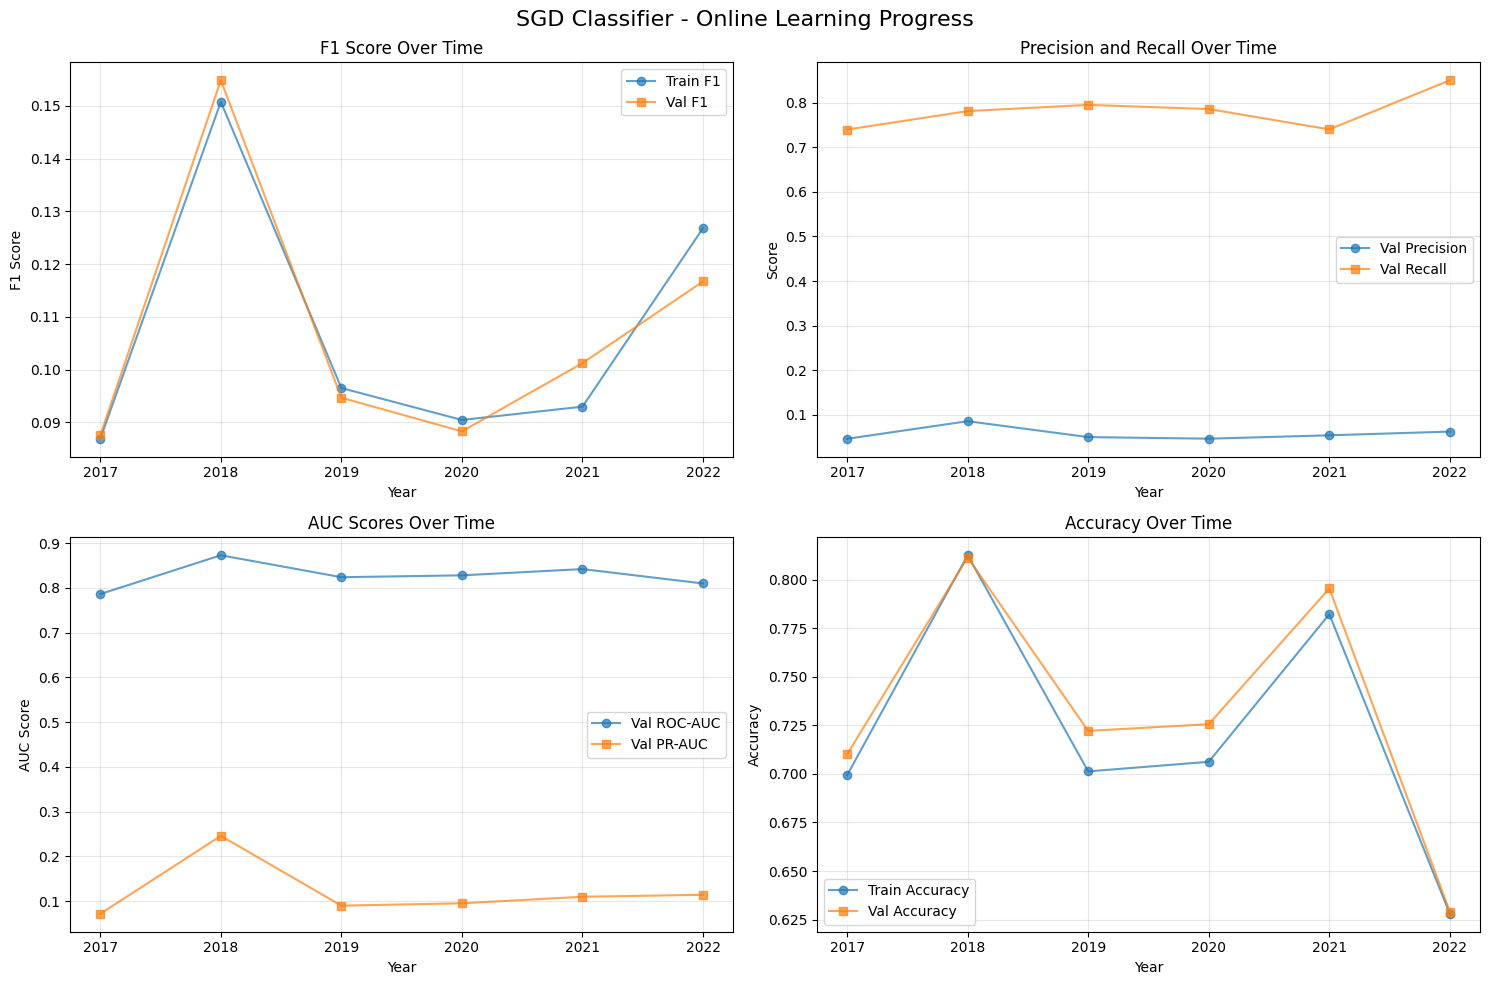


Summary Statistics (Validation Set):
       val_accuracy  val_precision  val_recall    val_f1  val_roc_auc  \
count      6.000000       6.000000    6.000000  6.000000     6.000000   
mean       0.732276       0.057758    0.781793  0.107209     0.826948   
std        0.065596       0.015052    0.040934  0.025688     0.029342   
min        0.629143       0.046513    0.739536  0.087521     0.785989   
25%        0.713086       0.047659    0.750182  0.089877     0.813147   
50%        0.723845       0.052327    0.783205  0.097941     0.825757   
75%        0.777950       0.060578    0.792509  0.112846     0.838338   
max        0.811337       0.085947    0.850025  0.154851     0.872712   

       val_pr_auc  
count    6.000000  
mean     0.120907  
std      0.062967  
min      0.071521  
25%      0.091035  
50%      0.102303  
75%      0.112855  
max      0.245662  


In [59]:
# Convert history to DataFrame
history_df = pd.DataFrame(training_history)

# Plot learning curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SGD Classifier - Online Learning Progress', fontsize=16)

# Plot 1: F1 Score
ax = axes[0, 0]
ax.plot(history_df['year'], history_df['train_f1'], label='Train F1', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_f1'], label='Val F1', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Precision and Recall
ax = axes[0, 1]
ax.plot(history_df['year'], history_df['val_precision'], label='Val Precision', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_recall'], label='Val Recall', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: ROC-AUC and PR-AUC
ax = axes[1, 0]
ax.plot(history_df['year'], history_df['val_roc_auc'], label='Val ROC-AUC', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_pr_auc'], label='Val PR-AUC', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('AUC Score')
ax.set_title('AUC Scores Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Accuracy
ax = axes[1, 1]
ax.plot(history_df['year'], history_df['train_accuracy'], label='Train Accuracy', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_accuracy'], label='Val Accuracy', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display summary statistics
print('\nSummary Statistics (Validation Set):')
print(history_df[['val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_roc_auc', 'val_pr_auc']].describe())

## 6. Final Evaluation on Test Set

In [60]:
# Evaluate on entire test set (years 1..end, year 0 skipped) with per-year scalers
print('Evaluating on test set...')

y_test_all = []
y_pred_all = []
y_proba_all = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    
    # Load year-specific scaler
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_huber.pkl'
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        # Fallback to in-memory scaler (if training ran in this session)
        year_scaler = year_to_scaler.get(year_val)
    
    if year_scaler is None:
        print(f'Year {year_val}: scaler not found, skipping this year in test evaluation.')
        continue
    
    # Prepare test data for this year using its scaler
    X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)
    if len(X_test_year) == 0:
        print(f'Year {year_val}: skipped in test (no samples after NaN handling)')
        continue
    
    # Predictions for this year
    y_pred_year = model.predict(X_test_year)
    y_proba_year = model.predict_proba(X_test_year)[:, 1]
    
    # Accumulate
    y_test_all.append(y_test_year)
    y_pred_all.append(y_pred_year)
    y_proba_all.append(y_proba_year)

# Combine all years
if len(y_test_all) == 0:
    raise ValueError('No test samples available after NaN handling. Consider adjusting preprocessing.')

y_test = np.concatenate(y_test_all)
y_test_pred = np.concatenate(y_pred_all)
y_test_proba = np.concatenate(y_proba_all)

print(f'Test set size: {y_test.shape[0]} samples')

# Metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print('\n=== TEST SET RESULTS ===')
print(f'Accuracy:  {test_acc:.4f}')
print(f'Precision: {test_prec:.4f}')
print(f'Recall:    {test_rec:.4f}')
print(f'F1 Score:  {test_f1:.4f}')
print(f'ROC-AUC:   {test_roc_auc:.4f}')
print(f'PR-AUC:    {test_pr_auc:.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print('\nConfusion Matrix:')
print(cm)
print(f'\nTrue Negatives:  {cm[0, 0]}')
print(f'False Positives: {cm[0, 1]}')
print(f'False Negatives: {cm[1, 0]}')
print(f'True Positives:  {cm[1, 1]}')

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, target_names=['No Disturbance', 'Disturbance']))

Evaluating on test set...


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 1
  Dropped 2098 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 2
  Dropped 2036 samples with NaN values (0.2%) for year 2


...

  Dropped 289 samples with invalid labels (class 255) for year 4
  Dropped 1898 samples with NaN values (0.1%) for year 4


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 5
  Dropped 2109 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 6
  Dropped 1252 samples with NaN values (0.1%) for year 6
Test set size: 7690705 samples

=== TEST SET RESULTS ===
Accuracy:  0.6178
Precision: 0.0490
Recall:    0.8749
F1 Score:  0.0928
ROC-AUC:   0.8262
PR-AUC:    0.1041

Confusion Matrix:
[[4601261 2917608]
 [  21491  150345]]

True Negatives:  4601261
False Positives: 2917608
False Negatives: 21491
True Positives:  150345

Classification Report:
                precision    recall  f1-score   support

No Disturbance       1.00      0.61      0.76   7518869
   Disturbance       0.05      0.87      0.09    171836

      accuracy                           0.62   7690705
     macro avg       0.52      0.74      0.43   7690705
  weighted avg       0.97      0.62      0.74   7690705



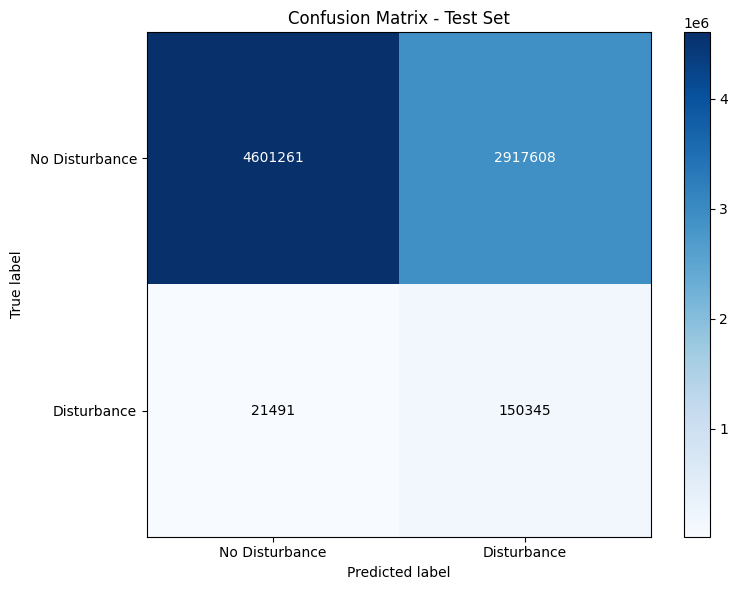

In [61]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['No Disturbance', 'Disturbance'],
       yticklabels=['No Disturbance', 'Disturbance'],
       title='Confusion Matrix - Test Set',
       ylabel='True label',
       xlabel='Predicted label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

## 7. Save Model and Results

In [62]:
import pickle

# Save the trained model
model_path = Path('.') / 'sgd_classifier_huber_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f'✓ Model saved to {model_path}')

# Per-year scalers are already saved under models_huber/ as scaler_year_YYYY_huber.pkl
print('✓ Per-year scalers saved under models_huber/ (scaler_year_YYYY_huber.pkl)')

# Save training history
history_path = Path('.') / 'sgd_classifier_huber_history.csv'
history_df.to_csv(history_path, index=False)
print(f'✓ Training history saved to {history_path}')

# Save test results
test_results = {
    'accuracy': test_acc,
    'precision': test_prec,
    'recall': test_rec,
    'f1_score': test_f1,
    'roc_auc': test_roc_auc,
    'pr_auc': test_pr_auc,
    'confusion_matrix': cm.tolist()
}

results_path = Path('.') / 'sgd_classifier_huber_test_results.json'
import json
with open(results_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f'✓ Test results saved to {results_path}')

✓ Model saved to sgd_classifier_huber_model.pkl
✓ Per-year scalers saved under models_huber/ (scaler_year_YYYY_huber.pkl)
✓ Training history saved to sgd_classifier_huber_history.csv
✓ Test results saved to sgd_classifier_huber_test_results.json


## 8. Feature Importance Analysis


Top 15 Most Important Features:


,Feature,Coefficient,Abs_Coefficient
8,NDVI,-2.544095,2.544095
9,NDWI,-2.361010,2.361010
1,S2_B03,1.891122,1.891122
2,S2_B04,-1.871442,1.871442
5,S2_B07,-1.712365,1.712365
6,S2_B8A,1.552444,1.552444
4,S2_B06,-0.761299,0.761299
3,S2_B05,0.480753,0.480753
0,S2_B02,-0.208651,0.208651
10,NBR,-0.136540,0.136540


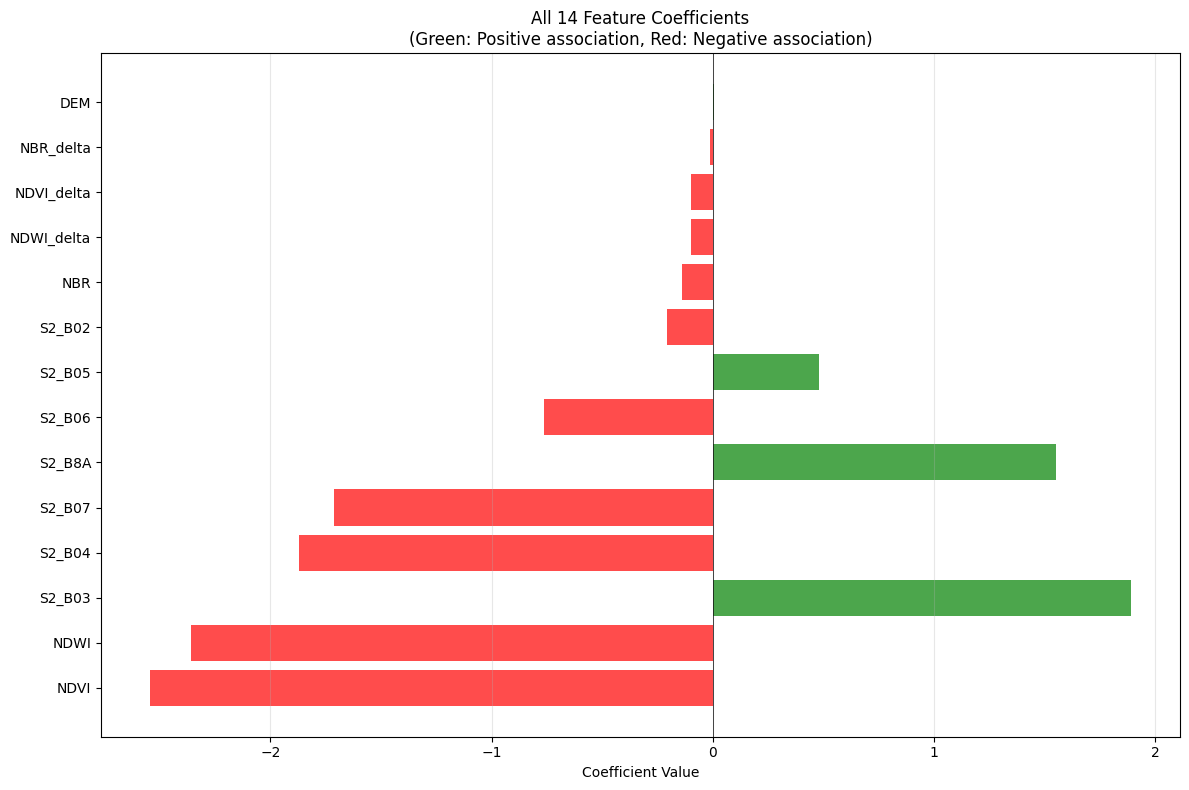

In [63]:
# Extract feature coefficients from the model
coefficients = model.coef_[0]

# Create feature names
s2_bands = ds['s2_band'].values
feature_names = [f'S2_{band}' for band in s2_bands]
feature_names.extend(['DEM', 'NDVI', 'NDWI'])
if 'nbr' in ds.data_vars:
    feature_names.append('NBR')
# Note: temporal deltas only for year > 0, but averaged in coefficients
if 'ndvi_delta' in ds.data_vars:
    feature_names.extend(['NDVI_delta', 'NDWI_delta'])
    if 'nbr_delta' in ds.data_vars:
        feature_names.append('NBR_delta')

# Ensure we have the right number of feature names
if len(feature_names) < len(coefficients):
    # Add generic names for any missing features
    for i in range(len(feature_names), len(coefficients)):
        feature_names.append(f'Feature_{i}')
elif len(feature_names) > len(coefficients):
    feature_names = feature_names[:len(coefficients)]

# Create DataFrame of feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})
importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

print('\nTop 15 Most Important Features:')
display(importance_df.head(15))

# Plot feature importance - display all features
fig, ax = plt.subplots(figsize=(12, max(8, len(importance_df) * 0.3)))
top_n = len(importance_df)
top_features = importance_df.head(top_n)
colors = ['red' if c < 0 else 'green' for c in top_features['Coefficient']]
ax.barh(range(top_n), top_features['Coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title(f'All {top_n} Feature Coefficients\n(Green: Positive association, Red: Negative association)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## 9. Per-Year Model Evaluation on Test Sets

PER-YEAR MODEL EVALUATION ON TEST SETS


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 1
  Dropped 2098 samples with NaN values (0.2%) for year 1

Year 2017 (Test set: 1281605 samples):
  Accuracy:  0.7108
  Precision: 0.0488
  Recall:    0.8097
  F1 Score:  0.0920
  ROC-AUC:   0.8324
  PR-AUC:    0.0948


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 2
  Dropped 2036 samples with NaN values (0.2%) for year 2

Year 2018 (Test set: 1281667 samples):
  Accuracy:  0.8134
  Precision: 0.0904
  Recall:    0.8080
  F1 Score:  0.1626
  ROC-AUC:   0.8833
  PR-AUC:    0.2599


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 5
  Dropped 2109 samples with NaN values (0.2%) for year 5

Year 2021 (Test set: 1281594 samples):
  Accuracy:  0.7820
  Precision: 0.0567
  Recall:    0.7621
  F1 Score:  0.1056
  ROC-AUC:   0.8454
  PR-AUC:    0.1133


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 6
  Dropped 1252 samples with NaN values (0.1%) for year 6

Year 2022 (Test set: 1282451 samples):
  Accuracy:  0.6242
  Precision: 0.0703
  Recall:    0.8932
  F1 Score:  0.1304
  ROC-AUC:   0.8351
  PR-AUC:    0.1295

SUMMARY TABLE - PER-YEAR TEST RESULTS


,year,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1281605,0.710817,0.048771,0.809729,0.092001,0.832432,0.094787
1,2018,1281667,0.813391,0.090369,0.807999,0.162558,0.883303,0.259913
2,2019,1281583,0.708803,0.053601,0.787278,0.100369,0.818762,0.106122
3,2020,1281805,0.705954,0.061944,0.778093,0.114753,0.817722,0.126703
4,2021,1281594,0.782026,0.056743,0.762070,0.105621,0.845391,0.113349
5,2022,1282451,0.624230,0.070309,0.893236,0.130356,0.835063,0.129479


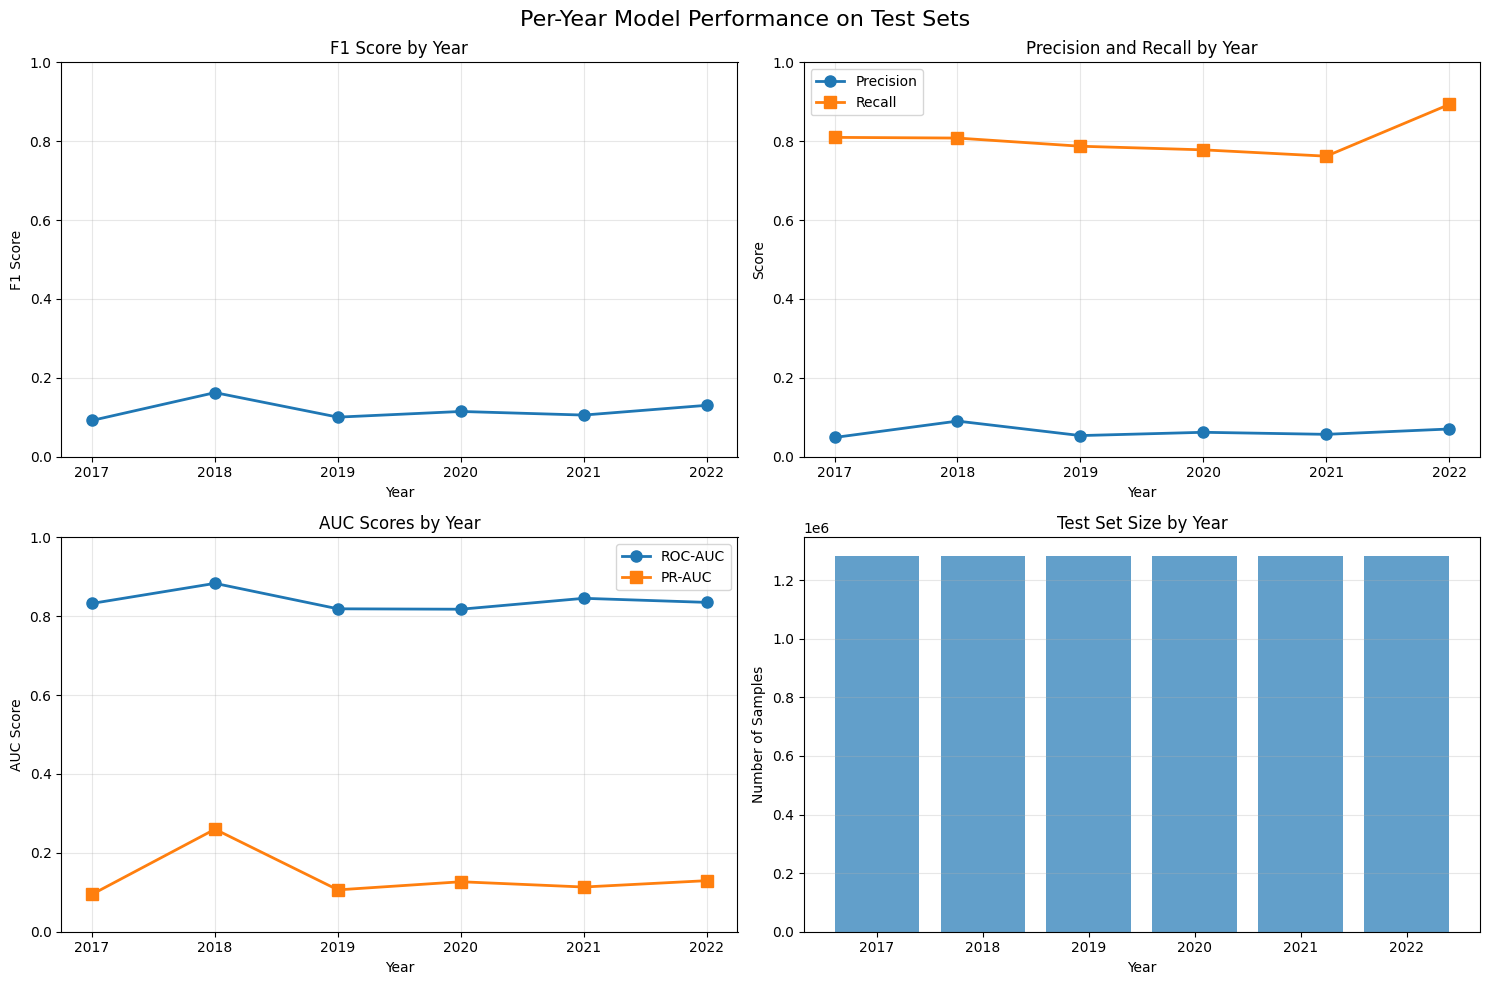

In [64]:
# Evaluate each year's model on the test set for that year
print('='*80)
print('PER-YEAR MODEL EVALUATION ON TEST SETS')
print('='*80)

yearly_results = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    year_model_path = models_dir / f'model_year_{int(year_val)}_huber.pkl'
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_huber.pkl'
    
    # Load the model for this year
    if not year_model_path.exists():
        print(f'\nYear {year_val}: Model file not found, skipping...')
        continue
    with open(year_model_path, 'rb') as f:
        year_model = pickle.load(f)
    
    # Load the scaler for this year
    if not scaler_path.exists():
        print(f'\nYear {year_val}: Scaler file not found, skipping...')
        continue
    with open(scaler_path, 'rb') as f:
        year_scaler = pickle.load(f)
    
    # Get test data for this year using its scaler
    X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)
    
    if len(X_test_year) == 0:
        print(f'\nYear {year_val}: No test samples available, skipping...')
        continue
    
    # Make predictions
    y_pred_year = year_model.predict(X_test_year)
    y_proba_year = year_model.predict_proba(X_test_year)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test_year, y_pred_year)
    prec = precision_score(y_test_year, y_pred_year, zero_division=0)
    rec = recall_score(y_test_year, y_pred_year, zero_division=0)
    f1 = f1_score(y_test_year, y_pred_year, zero_division=0)
    
    if len(np.unique(y_test_year)) > 1:
        roc_auc = roc_auc_score(y_test_year, y_proba_year)
        pr_auc = average_precision_score(y_test_year, y_proba_year)
    else:
        roc_auc = np.nan
        pr_auc = np.nan
    
    # Store results
    yearly_results.append({
        'year': year_val,
        'n_test_samples': len(X_test_year),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })
    
    # Print results
    print(f'\nYear {year_val} (Test set: {len(X_test_year)} samples):')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  PR-AUC:    {pr_auc:.4f}')

# Create DataFrame of yearly results
yearly_results_df = pd.DataFrame(yearly_results)

print('\n' + '='*80)
print('SUMMARY TABLE - PER-YEAR TEST RESULTS')
print('='*80)
display(yearly_results_df)

# Plot per-year performance metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Per-Year Model Performance on Test Sets', fontsize=16)

# Plot 1: F1 Score
ax = axes[0, 0]
ax.plot(yearly_results_df['year'], yearly_results_df['f1_score'], marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score by Year')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: Precision and Recall
ax = axes[0, 1]
ax.plot(yearly_results_df['year'], yearly_results_df['precision'], label='Precision', marker='o', linewidth=2, markersize=8)
ax.plot(yearly_results_df['year'], yearly_results_df['recall'], label='Recall', marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall by Year')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 3: AUC Scores
ax = axes[1, 0]
ax.plot(yearly_results_df['year'], yearly_results_df['roc_auc'], label='ROC-AUC', marker='o', linewidth=2, markersize=8)
ax.plot(yearly_results_df['year'], yearly_results_df['pr_auc'], label='PR-AUC', marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Year')
ax.set_ylabel('AUC Score')
ax.set_title('AUC Scores by Year')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 4: Sample sizes
ax = axes[1, 1]
ax.bar(yearly_results_df['year'], yearly_results_df['n_test_samples'], alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Samples')
ax.set_title('Test Set Size by Year')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Positive Rate Analysis by Split and Year

POSITIVE RATE ANALYSIS BY SPLIT AND YEAR


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 729 samples with invalid labels (class 255) for year 1
  Dropped 8837 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 1339 samples with NaN values (0.1%) for year 1


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 685 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 6
  Dropped 1252 samples with NaN values (0.1%) for year 6

Year 2022:
  Train: 3.06% (171390/5592392 samples)
  Val:   2.88% (36686/1272651 samples)
  Test:  3.15% (40435/1282451 samples)

SUMMARY TABLE - POSITIVE RATES BY SPLIT AND YEAR


,year,train_positive_rate,val_positive_rate,test_positive_rate
0,2017,0.018441,0.018801,0.018093
1,2018,0.020536,0.022133,0.022415
2,2019,0.020251,0.018277,0.020633
3,2020,0.018623,0.016915,0.024494
4,2021,0.015219,0.015570,0.016889
5,2022,0.030647,0.028826,0.031529


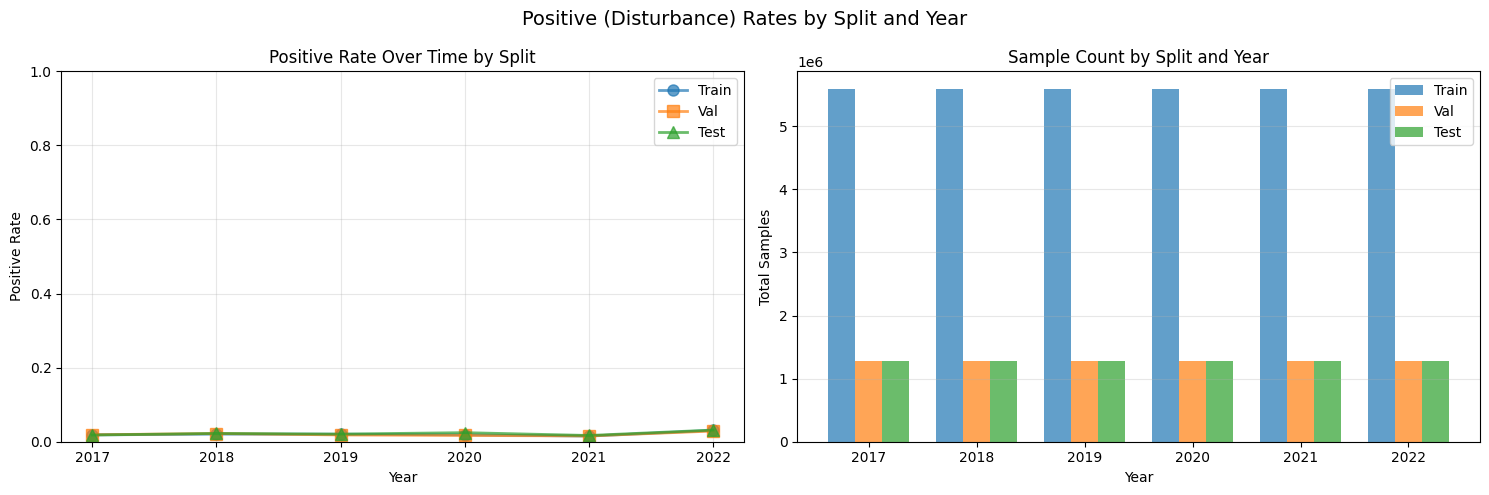


STATISTICS - POSITIVE RATES

Train Positive Rate:
count    6.000000
mean     0.020619
std      0.005265
min      0.015219
25%      0.018486
50%      0.019437
75%      0.020465
max      0.030647
Name: train_positive_rate, dtype: float64

Val Positive Rate:
count    6.000000
mean     0.020087
std      0.004816
min      0.015570
25%      0.017255
50%      0.018539
75%      0.021300
max      0.028826
Name: val_positive_rate, dtype: float64

Test Positive Rate:
count    6.000000
mean     0.022342
std      0.005287
min      0.016889
25%      0.018728
50%      0.021524
75%      0.023974
max      0.031529
Name: test_positive_rate, dtype: float64


In [65]:
# Calculate positive (disturbance) rates for each split by year
print('='*80)
print('POSITIVE RATE ANALYSIS BY SPLIT AND YEAR')
print('='*80)

split_positive_rates = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    
    # Load year-specific scaler (not strictly needed for labels, but keeps consistency)
    scaler_path = models_dir / f'scaler_year_{int(year_val)}.pkl'
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = year_to_scaler.get(year_val)
    
    # Get labels for each split using the year scaler (features normalized consistently)
    X_train_year, y_train_year, _ = prepare_features_for_year(ds, train_pixel_indices, year_idx, scaler=year_scaler)
    X_val_year, y_val_year, _ = prepare_features_for_year(ds, val_pixel_indices, year_idx, scaler=year_scaler)
    X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)
    
    # Skip if no data
    if len(y_train_year) == 0 or len(y_val_year) == 0 or len(y_test_year) == 0:
        print(f'\nYear {year_val}: Skipped (missing data in one or more splits)')
        continue
    
    # Calculate positive rates
    train_pos_rate = (y_train_year == 1).sum() / len(y_train_year)
    val_pos_rate = (y_val_year == 1).sum() / len(y_val_year)
    test_pos_rate = (y_test_year == 1).sum() / len(y_test_year)
    
    # Store results
    split_positive_rates.append({
        'year': year_val,
        'train_positive_rate': train_pos_rate,
        'train_total_samples': len(y_train_year),
        'train_positive_count': (y_train_year == 1).sum(),
        'val_positive_rate': val_pos_rate,
        'val_total_samples': len(y_val_year),
        'val_positive_count': (y_val_year == 1).sum(),
        'test_positive_rate': test_pos_rate,
        'test_total_samples': len(y_test_year),
        'test_positive_count': (y_test_year == 1).sum()
    })
    
    # Print results
    print(f'\nYear {year_val}:')
    print(f'  Train: {train_pos_rate:.2%} ({(y_train_year == 1).sum()}/{len(y_train_year)} samples)')
    print(f'  Val:   {val_pos_rate:.2%} ({(y_val_year == 1).sum()}/{len(y_val_year)} samples)')
    print(f'  Test:  {test_pos_rate:.2%} ({(y_test_year == 1).sum()}/{len(y_test_year)} samples)')

# Create DataFrame of positive rates
positive_rates_df = pd.DataFrame(split_positive_rates)

print('\n' + '='*80)
print('SUMMARY TABLE - POSITIVE RATES BY SPLIT AND YEAR')
print('='*80)
display(positive_rates_df[['year', 'train_positive_rate', 'val_positive_rate', 'test_positive_rate']])

# Plot positive rates by split
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Positive (Disturbance) Rates by Split and Year', fontsize=14)

# Plot 1: Positive rates by year
ax = axes[0]
ax.plot(positive_rates_df['year'], positive_rates_df['train_positive_rate'], 
        label='Train', marker='o', linewidth=2, markersize=8, alpha=0.7)
ax.plot(positive_rates_df['year'], positive_rates_df['val_positive_rate'], 
        label='Val', marker='s', linewidth=2, markersize=8, alpha=0.7)
ax.plot(positive_rates_df['year'], positive_rates_df['test_positive_rate'], 
        label='Test', marker='^', linewidth=2, markersize=8, alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Positive Rate')
ax.set_title('Positive Rate Over Time by Split')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: Sample counts by split
ax = axes[1]
x_pos = np.arange(len(positive_rates_df))
width = 0.25
ax.bar(x_pos - width, positive_rates_df['train_total_samples'], width, label='Train', alpha=0.7)
ax.bar(x_pos, positive_rates_df['val_total_samples'], width, label='Val', alpha=0.7)
ax.bar(x_pos + width, positive_rates_df['test_total_samples'], width, label='Test', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Total Samples')
ax.set_title('Sample Count by Split and Year')
ax.set_xticks(x_pos)
ax.set_xticklabels([int(y) for y in positive_rates_df['year']])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print('\n' + '='*80)
print('STATISTICS - POSITIVE RATES')
print('='*80)
print('\nTrain Positive Rate:')
print(positive_rates_df['train_positive_rate'].describe())
print('\nVal Positive Rate:')
print(positive_rates_df['val_positive_rate'].describe())
print('\nTest Positive Rate:')
print(positive_rates_df['test_positive_rate'].describe())

## 11.Final Model evaluation on each year's test set

In [66]:
# Evaluate the final trained model on each year's test set (summary table)
print('='*80)
print('FINAL MODEL EVALUATION ON EACH YEAR\'S TEST SET')
print('='*80)

final_model_results = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    scaler_path = models_dir / f'scaler_year_{int(year_val)}.pkl'
    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            year_scaler = pickle.load(f)
    else:
        year_scaler = year_to_scaler.get(year_val)
    if year_scaler is None:
        print(f'Year {year_val}: Scaler not found, skipping...')
        continue

    X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, year_idx, scaler=year_scaler)
    if len(X_test_year) == 0:
        continue

    y_pred = model.predict(X_test_year)
    try:
        y_proba = model.predict_proba(X_test_year)[:, 1]
    except Exception:
        y_proba = None

    acc = accuracy_score(y_test_year, y_pred)
    prec = precision_score(y_test_year, y_pred, zero_division=0)
    rec = recall_score(y_test_year, y_pred, zero_division=0)
    f1 = f1_score(y_test_year, y_pred, zero_division=0)

    if y_proba is not None and len(np.unique(y_test_year)) > 1:
        roc_auc = roc_auc_score(y_test_year, y_proba)
        pr_auc = average_precision_score(y_test_year, y_proba)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    final_model_results.append({
        'year': year_val,
        'n_test_samples': len(X_test_year),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

final_model_results_df = pd.DataFrame(final_model_results)

print('\n' + '='*80)
print('SUMMARY TABLE - FINAL MODEL ON PER-YEAR TEST SETS')
print('='*80)
display(final_model_results_df)

FINAL MODEL EVALUATION ON EACH YEAR'S TEST SET


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 1
  Dropped 2098 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 2
  Dropped 2036 samples with NaN values (0.2%) for year 2


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 5
  Dropped 2109 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 6
  Dropped 1252 samples with NaN values (0.1%) for year 6

SUMMARY TABLE - FINAL MODEL ON PER-YEAR TEST SETS


,year,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1281605,0.625648,0.040460,0.866828,0.077312,0.825754,0.081346
1,2018,1281667,0.610751,0.049224,0.893522,0.093307,0.842477,0.139787
2,2019,1281583,0.621930,0.045510,0.867337,0.086482,0.815585,0.086473
3,2020,1281805,0.611976,0.051423,0.850713,0.096985,0.807244,0.105532
4,2021,1281594,0.612486,0.036700,0.869161,0.070426,0.822600,0.083543
5,2022,1282451,0.624230,0.070309,0.893236,0.130356,0.835063,0.129479


## 12. Cumulative Test Set Evaluation

CUMULATIVE TEST SET EVALUATION


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 1
  Dropped 2098 samples with NaN values (0.2%) for year 1

Year 2017 model on cumulative test set (2017-2017):
  Test samples: 1,281,605
  Accuracy:  0.7108
  Precision: 0.0488
  Recall:    0.8097
  F1 Score:  0.0920
  ROC-AUC:   0.8324
  PR-AUC:    0.0948


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 1
  Dropped 2098 samples with NaN values (0.2%) for year 1


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 5
  Dropped 2109 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_17136\1399877788.py:27: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 289 samples with invalid labels (class 255) for year 6
  Dropped 1252 samples with NaN values (0.1%) for year 6

Year 2022 model on cumulative test set (2017-2022):
  Test samples: 7,690,705
  Accuracy:  0.5749
  Precision: 0.0445
  Recall:    0.8807
  F1 Score:  0.0847
  ROC-AUC:   0.8192
  PR-AUC:    0.1004

SUMMARY TABLE - CUMULATIVE TEST SET RESULTS


,year,n_test_samples,years_included,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1281605,2017-2017,0.710817,0.048771,0.809729,0.092001,0.832432,0.094787
1,2018,2563272,2017-2018,0.897103,0.092636,0.463933,0.154435,0.679290,0.156003
2,2019,3844855,2017-2019,0.618103,0.043430,0.843657,0.082608,0.817718,0.111877
3,2020,5126660,2017-2020,0.762210,0.063981,0.741554,0.117799,0.826915,0.113269
4,2021,6408254,2017-2021,0.637239,0.043051,0.786288,0.081633,0.799584,0.098607
5,2022,7690705,2017-2022,0.574875,0.044505,0.880671,0.084728,0.819196,0.100353


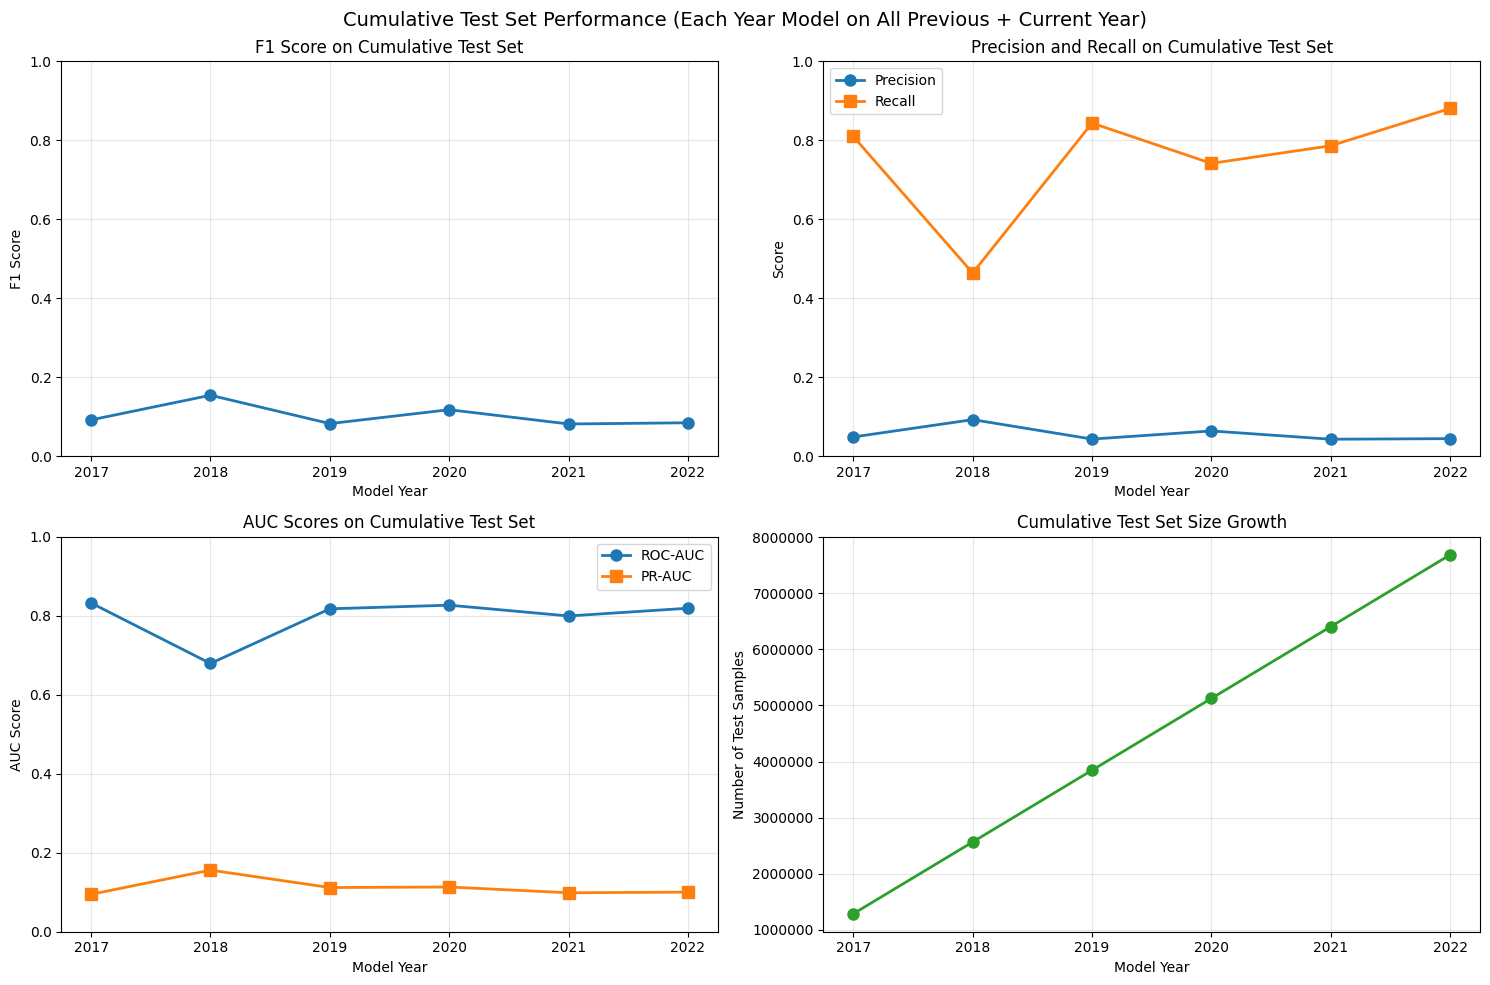

In [67]:
# Evaluate each year's model on cumulative test sets (that year + all previous years)
print('='*80)
print('CUMULATIVE TEST SET EVALUATION')
print('='*80)

cumulative_results = []

for year_idx in range(1, n_years):
    year_val = year_values[year_idx]
    year_model_path = models_dir / f'model_year_{int(year_val)}_huber.pkl'
    scaler_path = models_dir / f'scaler_year_{int(year_val)}_huber.pkl'
    
    # Load the model for this year
    if not year_model_path.exists():
        print(f'\nYear {year_val}: Model file not found, skipping...')
        continue
    with open(year_model_path, 'rb') as f:
        year_model = pickle.load(f)
    
    # Load the scaler for this year
    if not scaler_path.exists():
        print(f'\nYear {year_val}: Scaler file not found, skipping...')
        continue
    with open(scaler_path, 'rb') as f:
        year_scaler = pickle.load(f)
    
    # Accumulate test data from year 1 up to current year,
    # scaled using the current year's scaler for consistency
    X_cumulative = []
    y_cumulative = []
    
    for past_year_idx in range(1, year_idx + 1):
        X_test_year, y_test_year, _ = prepare_features_for_year(ds, test_pixel_indices, past_year_idx, scaler=year_scaler)
        if len(X_test_year) > 0:
            X_cumulative.append(X_test_year)
            y_cumulative.append(y_test_year)
    
    # Skip if no cumulative data
    if len(X_cumulative) == 0:
        print(f'\nYear {year_val}: No cumulative test data available, skipping...')
        continue
    
    # Combine all accumulated test data
    X_test_cumulative = np.vstack(X_cumulative)
    y_test_cumulative = np.concatenate(y_cumulative)
    
    # Make predictions
    y_pred_cumulative = year_model.predict(X_test_cumulative)
    y_proba_cumulative = year_model.predict_proba(X_test_cumulative)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test_cumulative, y_pred_cumulative)
    prec = precision_score(y_test_cumulative, y_pred_cumulative, zero_division=0)
    rec = recall_score(y_test_cumulative, y_pred_cumulative, zero_division=0)
    f1 = f1_score(y_test_cumulative, y_pred_cumulative, zero_division=0)
    
    if len(np.unique(y_test_cumulative)) > 1:
        roc_auc = roc_auc_score(y_test_cumulative, y_proba_cumulative)
        pr_auc = average_precision_score(y_test_cumulative, y_proba_cumulative)
    else:
        roc_auc = np.nan
        pr_auc = np.nan
    
    # Store results
    cumulative_results.append({
        'year': year_val,
        'n_test_samples': len(X_test_cumulative),
        'years_included': f'2017-{int(year_val)}',
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })
    
    # Print results
    print(f'\nYear {year_val} model on cumulative test set (2017-{int(year_val)}):')
    print(f'  Test samples: {len(X_test_cumulative):,}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  PR-AUC:    {pr_auc:.4f}')

# Create DataFrame of cumulative results
cumulative_results_df = pd.DataFrame(cumulative_results)

print('\n' + '='*80)
print('SUMMARY TABLE - CUMULATIVE TEST SET RESULTS')
print('='*80)
display(cumulative_results_df)

# Plot cumulative performance metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Cumulative Test Set Performance (Each Year Model on All Previous + Current Year)', fontsize=14)

# Plot 1: F1 Score
ax = axes[0, 0]
ax.plot(cumulative_results_df['year'], cumulative_results_df['f1_score'], marker='o', linewidth=2, markersize=8, color='tab:blue')
ax.set_xlabel('Model Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score on Cumulative Test Set')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: Precision and Recall
ax = axes[0, 1]
ax.plot(cumulative_results_df['year'], cumulative_results_df['precision'], label='Precision', marker='o', linewidth=2, markersize=8)
ax.plot(cumulative_results_df['year'], cumulative_results_df['recall'], label='Recall', marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Model Year')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall on Cumulative Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 3: AUC Scores
ax = axes[1, 0]
ax.plot(cumulative_results_df['year'], cumulative_results_df['roc_auc'], label='ROC-AUC', marker='o', linewidth=2, markersize=8)
ax.plot(cumulative_results_df['year'], cumulative_results_df['pr_auc'], label='PR-AUC', marker='s', linewidth=2, markersize=8)
ax.set_xlabel('Model Year')
ax.set_ylabel('AUC Score')
ax.set_title('AUC Scores on Cumulative Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Plot 4: Sample size growth
ax = axes[1, 1]
ax.plot(cumulative_results_df['year'], cumulative_results_df['n_test_samples'], marker='o', linewidth=2, markersize=8, color='tab:green')
ax.set_xlabel('Model Year')
ax.set_ylabel('Number of Test Samples')
ax.set_title('Cumulative Test Set Size Growth')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## 13. Side-by-Side Comparison of All Evaluation Approaches

In [68]:
# Compare all three evaluation approaches with separate tables
print('='*80)
print('EVALUATION RESULTS: THREE SEPARATE APPROACHES')
print('='*80)

# Table 1: Final Model on each year
print('\n' + '='*80)
print('TABLE 1: Final Model (trained on all years) evaluated on each year')
print('='*80)
table1 = final_model_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table1)

# Table 2: Year-specific Model on that year
print('\n' + '='*80)
print('TABLE 2: Year-Specific Model evaluated on that year only')
print('='*80)
table2 = yearly_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table2)

# Table 3: Year-specific Model on cumulative test set
print('\n' + '='*80)
print('TABLE 3: Year-Specific Model evaluated on cumulative test set (all years up to that year)')
print('='*80)
table3 = cumulative_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table3)




EVALUATION RESULTS: THREE SEPARATE APPROACHES

TABLE 1: Final Model (trained on all years) evaluated on each year


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.625648,0.040460,0.866828,0.077312,0.825754,0.081346,1281605
1,2018,0.610751,0.049224,0.893522,0.093307,0.842477,0.139787,1281667
2,2019,0.621930,0.045510,0.867337,0.086482,0.815585,0.086473,1281583
3,2020,0.611976,0.051423,0.850713,0.096985,0.807244,0.105532,1281805
4,2021,0.612486,0.036700,0.869161,0.070426,0.822600,0.083543,1281594
5,2022,0.624230,0.070309,0.893236,0.130356,0.835063,0.129479,1282451



TABLE 2: Year-Specific Model evaluated on that year only


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.710817,0.048771,0.809729,0.092001,0.832432,0.094787,1281605
1,2018,0.813391,0.090369,0.807999,0.162558,0.883303,0.259913,1281667
2,2019,0.708803,0.053601,0.787278,0.100369,0.818762,0.106122,1281583
3,2020,0.705954,0.061944,0.778093,0.114753,0.817722,0.126703,1281805
4,2021,0.782026,0.056743,0.762070,0.105621,0.845391,0.113349,1281594
5,2022,0.624230,0.070309,0.893236,0.130356,0.835063,0.129479,1282451



TABLE 3: Year-Specific Model evaluated on cumulative test set (all years up to that year)


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.710817,0.048771,0.809729,0.092001,0.832432,0.094787,1281605
1,2018,0.897103,0.092636,0.463933,0.154435,0.679290,0.156003,2563272
2,2019,0.618103,0.043430,0.843657,0.082608,0.817718,0.111877,3844855
3,2020,0.762210,0.063981,0.741554,0.117799,0.826915,0.113269,5126660
4,2021,0.637239,0.043051,0.786288,0.081633,0.799584,0.098607,6408254
5,2022,0.574875,0.044505,0.880671,0.084728,0.819196,0.100353,7690705
